# Part 1: Library Importing

In [13]:

# Load model directly
import argparse
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
from copy import deepcopy
import re
from nltk.translate.bleu_score import sentence_bleu
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoTokenizer, BertForMaskedLM, BertConfig

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.functional import cross_entropy
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torch.utils.data import DataLoader, Subset, RandomSampler
torch.set_default_dtype(torch.float32)
# torch.autograd.set_detect_anomaly(True)
import sys
sys.path.append("..")
# from llmrequest import requestNoDf
# from llmrequest import request
from utils import *

import nltk
from nltk.corpus import wordnet as wn
import ast
import gensim.downloader as api
import math


In [14]:
import pathlib
import textwrap

import google.generativeai as genai
import json
import torch

from IPython.display import display
from IPython.display import Markdown

genai.configure(api_key="REDACTED_GOOGLE_API_KEY_SET_VIA_ENV")
gemini = genai.GenerativeModel('gemini-pro')

# prompt_ = '''
# Context:
# you are an experiented english teacher who is very good at rating English text's quality. A text with good quality should be grammartivally correct and looks like human-written. Rate the multiple given sentences on a scale from 0 to 10, the higher the score, the better the quality.

# Examples:
# Inputs: ["Today's weather is so great! How about yours?", "I don't love like him.", "You looks great!"]
# Outputs: [9, 2, 10]
# This is because you rate the sentence as 9, 2, 10 respectively.

# Prompt:
# ["Steven Jobs didn't graduate from happiness.", "Hello, how is you?", "you look amazing!"]
# '''
prompt_ = '''
Context:
you are an experiented english teacher who is very good at rating English text's quality. A text with good quality should be grammartivally correct and looks like human-written. Rate the multiple given sentences on a scale from 0 to 10, the higher the score, the better the quality. You do not need to explain why you rate them your way, you only need to return a list of scores like this [].

Examples:
Inputs: ["Today's weather is so great! How about yours?", "I don't love like him.", "You looks great!"]
Outputs: [9,2,10]
This is because you rate the sentence as 9, 2, 10 respectively.

Inputs: ["This is awesome!", "Went to Dr. Anthony <unk> for first time for big sore on leg which was not healing."]
Outputs: [10,7]
This is because you rate the sentence as 10, 7 respectively.

Prompt:
Inputs: 
'''

outputs_ = '''
outputs:'''

def requestScore(batch_pred):
    global gemini
    global prompt_
    
    prompt = prompt_ + str(batch_pred) + outputs_
    try:
        response = gemini.generate_content(prompt, generation_config={'temperature': 0})
        reward_list = json.loads(response.text)
        if isinstance(reward_list, list) and len(reward_list) == 1:
            return reward_list[0]
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None


## 2.6 Evaluation

#### Read Dataframe

In [15]:
# current partition name

# ----------------------- 
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/BERTFineTuned_mnli_matched_val_0.7_8_80_0_0147_19July.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/BERTFineTuned_yelp_val_1.0_24_400_0_x.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/BERTMaskedLM_yelp_val_1.0_24_400_0_x.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/BERTFineTuned_imdb_val_1.0_48_1000_0.json'
# ----------------------- 

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/BERTFineTuned_mnli_mismatched_val_0.7_8_120_0_0147_19July.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/BERTFineTuned_mnli_matched_val_0.7_8_120_0_0147_19July.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/BERTMaskedLMRandom_mnli_matched_val_0.7_8_120_0_0147_19July.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/BERTMaskedLM_mnli_matched_val_0.7_8_120_0_0147_19July.json'

# mnli mismatched hypothesis
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/BERTMaskedLM_mnli_matched_val_0.7_8_80_0_0147_19July.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/BERTMaskedLMRandom_mnli_matched_val_0.7_8_80_0_0147_19July.json'

# mnli mismatched premise
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_12_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_160_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_12_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_BERTMaskedLMRandom_BERT_MNLI_mnli_matched_val_0.7_12_120_0.json'

# mnli match premise
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.8_2_1000_2.9205_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.9_2_1000_2.6550_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.9_2_1000_2.6550_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.9_2_1000_2.6550_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_0.9_2_1000_2.6550_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_20240918_174545_BERTMaskedLM_SBERT_NLI_mnli_matched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_20240920_105748_BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_20240920_042629_BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/eva_0922_105205BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_60_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/eva_0923_020243BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_60_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/eva_0926_210112BERTFineTuned_SBERT_NLI_mnli_matched_val_0.7_8_60_0.json'

# mnli match hypothesis
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240914_0110_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_60_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240914_0110_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240914_0110_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_60_0.json'
# # evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240914_0111_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240918_174618_BERTMaskedLM_SBERT_NLI_mnli_matched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/evaluation_20240920_094321_BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/eva_0922_103259BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_40_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/eva_0923_104234BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_60_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/hypothesis/eva_0923_104217BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_40_0.json'

# mnli mismatched premise
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_BERTFineTuned_ROBERTA_MNLI_mnli_mismatched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_BERTFineTuned_ROBERTA_MNLI_mnli_mismatched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_20240920_144724_BERTMaskedLM_BERT_MNLI_mnli_mismatched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/eva_0923_022746_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_60_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/eva_0923_022833_BERTMaskedLM_BERT_MNLI_mnli_mismatched_val_0.7_8_60_0.json'

# # mnli mismatched hypothesis
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/evaluation_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_60_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/evaluation_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/premise/evaluation_BERTFineTuned_ROBERTA_MNLI_mnli_mismatched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/evaluation_BERTFineTuned_ROBERTA_MNLI_mnli_mismatched_val_0.7_8_80_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/evaluation_20240920_144803_BERTMaskedLM_BERT_MNLI_mnli_mismatched_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/eva_0923_022932_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_40_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli_mismatched/hypothesis/eva_0923_023019_BERTMaskedLM_BERT_MNLI_mnli_mismatched_val_0.7_8_40_0.json'

# snli premise
evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/eva_0923_105240_premise_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_60_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/evaluation_0.5_0_400_2.9763_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/evaluation_0.5_0_400_2.9763_BERTFineTuned_ROBERTA_SNLI_snli_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/evaluation_0.5_0_400_2.9763_BERTFineTuned_ROBERTA_SNLI_snli_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/evaluation_20240916_203850_0.5_0_400_2.9763_premise_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/archive0922/evaluation_20240920_104102_premise_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_120_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/eva_0923_105240_premise_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_60_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/eva_0923_150836_premise_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_60_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/premise/eva_0926_203640_premise_BERTMaskedLMRandom_BERT_SNLI_snli_val_0.7_8_60_0.json'

# snli hypothesis
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/eva_0923_151732_hypothesis_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_40_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_0.5_0_400_2.9763_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_0.5_0_400_2.9763_BERTFineTuned_ROBERTA_SNLI_snli_val_0.7_8_60_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_0.5_0_400_2.9763_BERTFineTuned_ROBERTA_SNLI_snli_val_0.7_8_80_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_20240920_104000_hypothesis_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_20240920_095923_hypothesis_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/evaluation_20240920_104017_hypothesis_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_80_0.json'

# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/eva_0923_151732_hypothesis_BERTFineTuned_BERT_SNLI_snli_val_0.7_8_40_0.json'
# evaluationPartition = ''
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/snli/hypothesis/eva_0923_105934_hypothesis_BERTMaskedLM_BERT_SNLI_snli_val_0.7_8_80_0.json'


# # random baselines
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_20240916_0510_BERTMaskedLMRandom_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'
# evaluationPartition = '/usa/taikun/rl-attack/2evaluation/mnli/premise/evaluation_20240916_0511_BERTMaskedLMRandom_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json'

df = pd.read_json(evaluationPartition)
df['srcPredLabel'] = df['srcPredProb'].apply(lambda x: x.index(max(x)))
df['srcMisclassFlags'] = df.apply(lambda row: 1 if row['srcPredLabel'] != row['srcLabel'] else 0, axis=1)
# df['advPredLabel'] = df['advPredProb'].apply(lambda x: x.index(max(x)))
print(len(df))
df.head(2)

# # printing some samples
# print(df.srcDocshl[0])
# print(df.advDocshl[0])
# print(df.sourceDocs[0])
# print(df.advDocs[0])
# df.head(3)


689


,srcDocshl,advDocshl,srcLabel,sourceDocs,advDocs,srcPredProb,advPredProb,avgQueries,targetInx,targetTokens,toTokens,attackSuccess Flags,AattackPatterns,docLen,srcPredLabel,srcMisclassFlags
0,A person in a black and green outfit is riding...,A person in a black and green outfit is riding...,"[[0.022027669474482002, 0.388864636421203, 0.5...",[A person in a black and green outfit is ridin...,[A person in a black and green outfit is ridin...,"[0.022027669474482002, 0.388864636421203, 0.58...","[0.022027669474482002, 0.388864636421203, 0.58...",5.108853,[],[],[],1,{},22,2,1
1,A person rolls down a hill riding a wagon as a...,A person rolls down a hill riding a wagon as a...,"[[0.09413783997297201, 0.016297832131385002, 0...",[A person rolls down a hill riding a wagon as ...,[A person rolls down a hill riding a wagon as ...,"[0.09413783997297201, 0.016297832131385002, 0....","[0.003115820465609, 0.907574832439422, 0.08930...",5.108853,[15],[child],[matter],1,{'15': 2187},24,2,1


sorted_token_counts [('Beta', 189), ('matter', 142), ('oversees', 107), ('intact', 55), ('##Ε', 48), ('kings', 47), ('Arabian', 47), ('ca', 42), ('connecting', 35), ('220', 29), ('merits', 28), ('km²', 26), ('valley', 24), ('filled', 19), ('Gathering', 19), ('Presidential', 16), ('burying', 15), ('##using', 10), ('##ì', 10), ('##uti', 7), ('interrupted', 6)]
Token Counts (from most frequent to least):
Beta: 189
matter: 142
oversees: 107


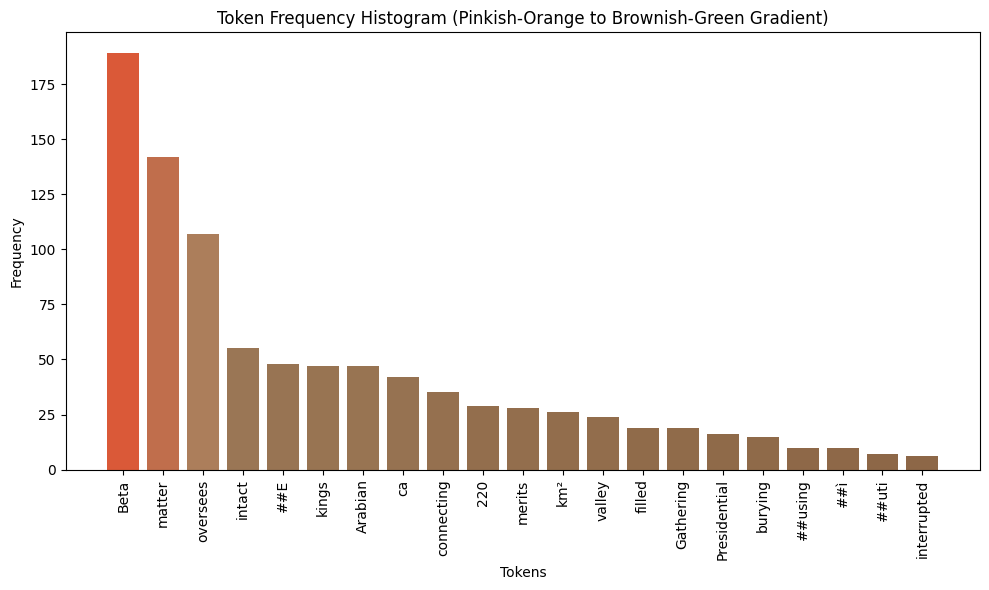

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Assume 'df' is a DataFrame that contains a column 'toTokens' with token lists
toTokens = [token for sublist in df['toTokens'] for token in sublist if isinstance(token, str)]
token_counts = Counter(toTokens)

# Sort the tokens by frequency in descending order
sorted_token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)

print('sorted_token_counts', sorted_token_counts)

# Convert sorted token_counts to separate lists of tokens and frequencies
tokens, frequencies = zip(*sorted_token_counts)

# Print out the raw token counts
print("Token Counts (from most frequent to least):")
num_tokens_cnt = 0
for token, freq in sorted_token_counts:
    num_tokens_cnt += 1
    if num_tokens_cnt == 4:
        break
    print(f"{token}: {freq}")

# Define the gradient colors transitioning from pinkish-orange to brownish-green
transition_colors = ['#8b6545', '#a58360', '#da5938']  # Pinkish-orange to brownish-green

# Create a custom colormap for the transition
cmap_transition = LinearSegmentedColormap.from_list("custom_transition", transition_colors)

# Normalize the frequencies to a range of 0 to 1 for color mapping
normalized_frequencies = [freq / max(frequencies) for freq in frequencies]

# Plot the token frequency histogram using the new transition gradient
plt.figure(figsize=(10, 6))
bars = plt.bar(tokens, frequencies, color=cmap_transition(normalized_frequencies))
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title("Token Frequency Histogram (Pinkish-Orange to Brownish-Green Gradient)")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()

img_name = evaluationPartition + '.png'
plt.savefig(img_name, dpi=300, bbox_inches='tight')

# Show the plot with the new gradient transition
plt.show()



In [17]:
# attack rate
def get_attack_rate(df):
    success_rate = df['attackSuccess Flags'].sum() / len(df['attackSuccess Flags'])
    return success_rate

# path length similarity


In [18]:
# Path Length Similarity
# Ensure WordNet data is downloaded
nltk.download('wordnet')

def get_path_similarity_(word1, word2):
    # print("word1", word1, "word2", word2)
    # Get the synsets for the words
    synsets1 = wn.synsets(word1)
    synsets2 = wn.synsets(word2)

    if not synsets1 or not synsets2:
        return 1.0

    max_similarity = 0
    for synset1 in synsets1:
        for synset2 in synsets2:
            similarity = synset1.path_similarity(synset2)
            if similarity and similarity > max_similarity:
                max_similarity = similarity

    if max_similarity == 0:
        return 0.0
    # print("max_similarity", max_similarity)
    return max_similarity

def get_path_similarity(df):
    wordSimilarity = []
    for i in range(len(df)):
        attackLen = len(df['AattackPatterns'][i])
        if attackLen > 0:
            targetTokens = df['targetTokens'][i][:attackLen]
            toTokens = df['toTokens'][i][:attackLen]
            s = 0.0
            for j in range(attackLen):        
                s += get_path_similarity_(targetTokens[j], toTokens[j])
            s = s/float(attackLen)
        else:
            s = 1.0
        # print(s)
        wordSimilarity.append(s)
        # wordSimilarity.extend(s)
        #print("sum(wordSimilarity)/len(wordSimilarity)", sum(wordSimilarity)/len(wordSimilarity))
        #print("wordSimilarity", wordSimilarity)
    return sum(wordSimilarity)/len(wordSimilarity), wordSimilarity


[nltk_data] Downloading package wordnet to /usa/taikun/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
#### Counter Fit Embedding Similarity

# import gensim
# import numpy as np

# # Load Counter-Fit embeddings
# counter_fit_path = './counter-fitted-vectors.txt'
# word_vectors = gensim.models.KeyedVectors.load_word2vec_format(counter_fit_path, binary=False)

# def get_embedding_similarity(word1, word2, word_vectors):
#     # Check if both words are in the model's vocabulary
#     if word1 in word_vectors.key_to_index and word2 in word_vectors.key_to_index:
#         # Get the vector embeddings for the words
#         vec1 = word_vectors[word1]
#         vec2 = word_vectors[word2]
        
#         # Calculate cosine similarity
#         similarity = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
#         return similarity
#     else:
#         # Return 0.0 if one of the words is not in the vocabulary
#         return 0.0


In [20]:
#### Embedding Similarity
import gensim.downloader as api
import numpy as np

# Load a pre-trained Word2Vec model
word_vectors = api.load("glove-wiki-gigaword-50")

def get_embedding_similarity(word1, word2):
    global word_vectors
    # Check if both words are in the model's vocabulary
    if word1 in word_vectors.key_to_index and word2 in word_vectors.key_to_index:
        # Get the vector embeddings for the words
        vec1 = word_vectors[word1]
        vec2 = word_vectors[word2]
        
        # Calculate cosine similarity
        similarity = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        return similarity
    else:
        # Return 0.0 if one of the words is not in the vocabulary
        return 0.0
    
def get_emb_similarity(df):
    df = df[df["attackSuccess Flags"]==1]
    df.reset_index(drop=True, inplace=True)
    
    embSimilarity = []
    for i in range(len(df)):
        #print(i, ' th')
        attackLen = len(df['AattackPatterns'][i])
        #print("attackLen", attackLen)
        if attackLen > 0:
            # print(attackLen)
            targetTokens = df['targetTokens'][i][:attackLen]
            # print(targetTokens)
            toTokens = df['toTokens'][i][:attackLen]
            s = 0.0
            for j in range(attackLen):        
                #print(get_path_similarity(targetTokens[j], toTokens[j]))
                s += get_embedding_similarity(targetTokens[j], toTokens[j])
            s = s/float(attackLen)
        else:
            s = 1.0
        embSimilarity.append(s)
    # return sum(embSimilarity)/ len(embSimilarity), embSimilarity
    return sum(embSimilarity)/ len(embSimilarity), embSimilarity
        

#### USE similarity

In [21]:
# def getUSEcosSimilarity(srcDocs, copyDocs):
#     # input 2 lists of documents 
#     import tensorflow_hub as hub
#     embed = hub.load("https://kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/1")
#     USEcosinSimilarity = []
#     sim_metric = torch.nn.CosineSimilarity(dim=1)
#     for src, copy in zip(srcDocs, copyDocs):
#         emb1, emb2 = embed([src, copy])["outputs"]
#         emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())
#         srcEmb = torch.unsqueeze(emb1, dim=0).to(device) # [embSz] -> [1, embSz]
#         advEmb = torch.unsqueeze(emb2, dim=0).to(device)
#         es = sim_metric(srcEmb, advEmb)
#         USEcosinSimilarity.append(es.item())
#     return USEcosinSimilarity.mean(), USEcosinSimilarity
    

In [22]:
# USE
import tensorflow_hub as hub

def get_angular_sim(emb1, emb2):
    cos_sim = torch.nn.CosineSimilarity(dim=1)(emb1, emb2)-1e-6
    return 1 - (torch.acos(cos_sim) / math.pi)

def get_use_cos_similarity(df, metric):
    df = df[df["attackSuccess Flags"]==1]
    df.reset_index(drop=True, inplace=True)
    
    
    embed = hub.load("https://kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/1")
    # emb1, emb2 = embed([
    #     "The quick brown fox jumps over the lazy dog.",
    #     "I am a sentence for which I would like to get its embedding"])["outputs"]
    # emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())

    USEcosinSimilarity = []
    cos_sims = []
    if metric == 'cos':
        sim_metric = torch.nn.CosineSimilarity(dim=1)
    elif metric == 'aug':
        sim_metric = get_angular_sim
    else:
        print("error loading USE similarity metrics")
        
    for i in range(len(df)):
    # for i in range(2):
        emb1, emb2 = embed([df['sourceDocs'][i], df['advDocs'][i]])["outputs"]
        emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())
        srcEmb = torch.unsqueeze(emb1, dim=0) # [embSz] -> [1, embSz]
        advEmb = torch.unsqueeze(emb2, dim=0) 
        es = sim_metric(srcEmb, advEmb)
        USEcosinSimilarity.append(es.item())
    return sum(USEcosinSimilarity)/len(USEcosinSimilarity), USEcosinSimilarity

In [23]:
def get_query_numbers(df):
    srcDocLen, attackedLen = [], []
    # for i in tqdm(range(len(df.sourceDocs))):
    for i in range(len(df.sourceDocs)):
        srcCount = len(df.sourceDocs[i].split())
        srcDocLen.append(srcCount)

        attLen = len(df.AattackPatterns[i])
        attackedLen.append(attLen)
    # # print(srcDocLen)
    # # print(attackedLen)

    df['srcDocLen'] = srcDocLen
    df['attackLen'] = attackedLen
    
    # print("avg attacked %: ", round(np.mean(attackedLen)/df.srcDocLen.mean(),4) * 100)
    # print("avg attacked tokens: ", np.mean(attackedLen))

    # # cntQueries
    # print("average document length: ", df.srcDocLen.mean())
    # print("advQueires without processing important tokens: ", df.avgQueries.mean())
    # print("avgQueries: ", df.srcDocLen.mean() + df.avgQueries.mean())
    
    avgTokenRate = round(np.mean(attackedLen)/df.srcDocLen.mean(),4) * 100
    avgNumAttackedTokens = np.mean(attackedLen)
    avgDocLen = df.srcDocLen.mean()
    avgQueriesNoIT = df.avgQueries.mean()
    avgQueries = (df.srcDocLen.mean() + df.avgQueries.mean())
    
    return avgTokenRate, avgNumAttackedTokens, avgDocLen, avgQueriesNoIT, avgQueries

In [24]:
def evaluationAll(jsoNamen):
    
    evaluationPartition = jsoNamen
    df = pd.read_json(evaluationPartition)
    df['sourceDocs'] = df['sourceDocs'].apply(lambda x: ' '.join(x))
    df['advDocs'] = df['advDocs'].apply(lambda x: ' '.join(x))
    df['srcPredLabel'] = df['srcPredProb'].apply(lambda x: x.index(max(x)))
    df['srcMisclassFlags'] = df.apply(lambda row: 1 if row['srcPredLabel'] != row['srcLabel'] else 0, axis=1)
    print("data size: ", len(df))
    
    attackRate = get_attack_rate(df)
    print("attack rate    : ", attackRate)
    avgTokenRate, avgNumAttackedTokens, avgDocLen, avgQueriesNoIT, avgQueries = get_query_numbers(df)

    print("document length: ", avgDocLen)
    print("num queriesnoIT: ", avgQueriesNoIT)  
    print("num queryies   : ", avgQueries)
    print("rate attkTokens: ", avgTokenRate)    
    print("num attkTokens : ", avgNumAttackedTokens)    
    
    try:
        pth, _ = get_path_similarity(df)
        print("pth similarity : ", pth)
    except:
        pass
    
    # avgQueries = df.iloc[0]['avgQueries']
    embS, _ = get_emb_similarity(df)
    print("emb similarity : ", embS)

    useCos, _ = get_use_cos_similarity(df, 'cos')
    print("USE cos simrty : ", useCos)
    useAug, _ = get_use_cos_similarity(df, 'aug')
    print("USE aug simrty : ", useAug)

# evaluationAll("yelp_val_BERTFineTuned.json")
# evaluationAll("yelp_val_BERTMaskedLM.json")
evaluationAll(evaluationPartition)

data size:  689
attack rate    :  0.9796806966618288
document length:  21.779390420899855
num queriesnoIT:  5.1088534107402035
num queryies   :  26.888243831640057
rate attkTokens:  6.140000000000001
num attkTokens :  1.3367198838896952
pth similarity :  0.4558349881989212
emb similarity :  0.264971606796182


2024-11-26 06:55:09.680001: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21359 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090 Ti, pci bus id: 0000:17:00.0, compute capability: 8.6
2024-11-26 06:55:09.680555: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22441 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090 Ti, pci bus id: 0000:65:00.0, compute capability: 8.6


USE cos simrty :  0.9255310245796486
USE aug simrty :  0.8900920027273672


# Other

In [25]:
# import time
# from tqdm import tqdm

# srcLLMScore, advLLMscore = [], []

# for i in tqdm(range(len(df.sourceDocs))):
#     time.sleep(2)  # Wait for seconds before processing each iteration
#     s = requestScore(df.sourceDocs[i])
#     srcLLMScore.append(s)
#     if i % 25 == 0:
#         print(srcLLMScore)

# print(srcLLMScore)

# for i in range(len(df.advDocs)):
#     time.sleep(2)  # Wait for 2 seconds before processing each iteration
#     s = requestScore(df.advDocs[i])
#     advLLMscore.append(s)
#     if i % 25 == 0:
#         print(advLLMscore)

# print(advLLMscore)

In [26]:
case study (temporary)

SyntaxError: invalid syntax (2006881360.py, line 1)

In [ ]:
# USE
import torch
import tensorflow_hub as hub

def get_angular_sim(emb1, emb2):
    cos_sim = torch.nn.CosineSimilarity(dim=1)(emb1, emb2)-1e-6
    return 1 - (torch.acos(cos_sim) / math.pi)

def get_use_cos_similarity(src_doc, adv_doc, metric='cos'):

    embed = hub.load("https://kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/1")
    # emb1, emb2 = embed([
    #     "The quick brown fox jumps over the lazy dog.",
    #     "I am a sentence for which I would like to get its embedding"])["outputs"]
    # emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())

    USEcosinSimilarity = []
    cos_sims = []
    if metric == 'cos':
        sim_metric = torch.nn.CosineSimilarity(dim=1)
    elif metric == 'aug':
        sim_metric = get_angular_sim
    else:
        print("error loading USE similarity metrics")
        
    emb1, emb2 = embed([src_doc, adv_doc])["outputs"]
    emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())
    srcEmb = torch.unsqueeze(emb1, dim=0) # [embSz] -> [1, embSz]
    advEmb = torch.unsqueeze(emb2, dim=0) 
    es = sim_metric(srcEmb, advEmb)
    USEcosinSimilarity.append(es.item())
    print(USEcosinSimilarity)


In [ ]:
embed = hub.load("https://kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/1")
emb1, emb2 = embed([
    "The quick brown fox jumps over the lazy dog.",
    "I am a sentence for which I would like to get its embedding"])["outputs"]
emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())

In [ ]:
embed = hub.load("https://kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/1")


In [ ]:
src_doc = '''uh i don't know i i have mixed emotions about him uh sometimes i like him but at the same times i love to see somebody beat him I like him for the most part, but would still enjoy seeing someone beat him.'''
adv_doc = '''uh i don't know i i have mixed emotions about him uh sometimes i like him but at the same times i love to see somebody beat him Romania CPU Article for 1791 most part, but would still enjoy seeing someone beat him.'''

emb1, emb2 = embed([
    src_doc,
    adv_doc])["outputs"]
emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())

emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())
srcEmb = torch.unsqueeze(emb1, dim=0) # [embSz] -> [1, embSz]
advEmb = torch.unsqueeze(emb2, dim=0) 
es = sim_metric(srcEmb, advEmb)
USEcosinSimilarity.append(es.item())
print(USEcosinSimilarity)

[0.8008664846420288]


In [ ]:
src_doc = '''uh i don't know i i have mixed emotions about him uh sometimes i like him but at the same times i love to see somebody beat him I like him for the most part, but would still enjoy seeing someone beat him.'''
adv_doc = '''uh i don't know i i have mixed emotions about him uh sometimes i like him but at the same times i love to see somebody beat him Romania CPU Article for 1791 most part, but would still enjoy seeing someone beat him.'''

emb1, emb2 = embed([
    src_doc,
    adv_doc])["outputs"]
emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())

emb1, emb2 = torch.tensor(emb1.numpy()), torch.tensor(emb2.numpy())
srcEmb = torch.unsqueeze(emb1, dim=0) # [embSz] -> [1, embSz]
advEmb = torch.unsqueeze(emb2, dim=0) 
es = sim_metric(srcEmb, advEmb)
USEcosinSimilarity.append(es.item())
print(USEcosinSimilarity)